# Analisis Valuasi dan Prediksi Return Hari Pertama Enam Emiten IPO BEI Juli 2026 Menggunakan Gradient Boosting dan Random Forest

Notebook ini mendokumentasikan proses analisis end-to-end untuk memprediksi return hari pertama (Return D1) dan return kumulatif 7 hari enam emiten yang melaksanakan IPO di Bursa Efek Indonesia pada Juli 2026, yaitu RANS, PRDL, BACH, JECX, EMMI, dan JELI.

Analisis dibagi menjadi dua tahap utama dalam satu notebook. **Tahap 1** mencakup eksplorasi data (EDA), deteksi dan penanganan outlier, serta feature engineering — termasuk keputusan metodologis seperti penetapan batas ARB flat 15%, penanganan Listing Board, dan perhitungan return kumulatif menggunakan formula perkalian. **Tahap 2** mencakup persiapan data dengan pipeline preprocessing yang bebas data leakage (train 80% / validation 20% / test 6 emiten target), perbandingan tiga model klasifikasi (Logistic Regression, Random Forest, Gradient Boosting) dan dua model regresi (Linear Regression, Random Forest Regressor), serta validasi aktual terhadap return yang terjadi di pasar setelah masing-masing emiten listing.

Model terpilih untuk prediksi akhir adalah **Gradient Boosting** untuk klasifikasi status Return D1 (ARA / Normal / ARB) dan **Random Forest** untuk estimasi return kumulatif 7 hari. Validasi pada 5 emiten yang sudah listing menunjukkan akurasi 40% (2/5), dengan kegagalan sistematis pada prediksi kelas ARA yang diduga disebabkan oleh class imbalance dan ketiadaan fitur oversubscription rate di dataset.

Sumber data yang digunakan adalah `e-IPO Data.csv` dari dataset publik Kaggle ([e-IPO Realtime Data](https://www.kaggle.com/datasets/fahmirk/e-ipo-realtime-data)). Pastikan file tersebut berada di direktori yang sama dengan notebook sebelum menjalankan sel pertama.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 150)

## 1. Gambaran Umum Dataset

In [ ]:
DATA_PATH = 'e-IPO Data.csv'  # ganti path ini jika ada versi data yang sudah diperbaiki

df = pd.read_csv(DATA_PATH)
print(f"Jumlah baris : {df.shape[0]}")
print(f"Jumlah kolom : {df.shape[1]}")
df.head(3)

<>:1: SyntaxWarning: invalid escape sequence '\M'
<>:1: SyntaxWarning: invalid escape sequence '\M'
C:\Users\user\AppData\Local\Temp\ipykernel_8808\2345199403.py:1: SyntaxWarning: invalid escape sequence '\M'
  DATA_PATH = 'D:\MY PORTO GW\Projek 1 - Analisis Saham IPO\Dataset\e-IPO Data.csv'  # ganti path ini jika ada versi data yang sudah diperbaiki


Jumlah baris : 251
Jumlah kolom : 33


,IPO Status,Ticker Code,Company Name,Sector,Subsector,Listing Board,Final Price (Rp),Return D1,Return D2,Return D3,Return D4,Return D5,Return D6,Return D7,Return from Listing Date,Line of Business,Address,Website,Number of shares offered,% of Total Shares,Participant Admin,Underwriter(s),Book Building Opening,Book Building Closing,Lowest Book Building Price (Rp),Highest Book Building Price (Rp),Opening of Offering Period,Closing of Offering Period,Closing Date,Distribution Date,Listing Date,Warrant per share ratio,Exercise Price (Warrant) (Rp)
0,Allotment,PRDL,PT Prodia Diagnostic Line Tbk,Healthcare,Healthcare Equipment,NaN,120.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Bergerak dalam bidang pembuatan dan pengolahan...,Kawasan Industri Jababeka III Jl. Tekno Boulev...,https://www.proline.co.id,522900000,30.00,AZ - SUCOR SEKURITAS,AZ,2026-06-18,2026-06-23,100,120,2026-07-01,2026-07-07,2026-07-07,2026-07-08,2026-07-09,0.0,NaN
1,Closed,EMMI,PT ESA MEDIKA MANDIRI TBK,Healthcare,Healthcare Supplies & Distributions,NaN,470.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Bergerak dalam perdagangan besar alat laborato...,"Esa 8 Building, Lantai 10 Jl. Ir.Sukarno No.Ka...",https://esamedikamandiri.com/,522857000,30.00,OD - BRI DANAREKSA SEKURITAS,"OD,RB,RS,IN",2026-06-22,2026-06-24,446,515,2026-07-02,2026-07-06,2026-07-06,2026-07-07,2026-07-08,0.0,NaN
2,Closed,BACH,PT Bach Multi Global Tbk.,Industrials,Diversified Industrial Trading,NaN,442.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Penjualan dan Penyewaan Genset serta Jasa Kons...,"Wisma 81, Jalan Cideng Barat No. 81, Gambir, J...",https://www.bachgroup.co.id/,615000000,15.06,AO - ERDIKHA ELIT SEKURITAS,"AO,PO",2026-06-22,2026-06-24,400,500,2026-07-02,2026-07-06,2026-07-06,2026-07-07,2026-07-08,0.0,NaN


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 251 entries, 0 to 250
Data columns (total 33 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   IPO Status                        251 non-null    object 
 1   Ticker Code                       251 non-null    object 
 2   Company Name                      251 non-null    object 
 3   Sector                            251 non-null    object 
 4   Subsector                         248 non-null    object 
 5   Listing Board                     231 non-null    object 
 6   Final Price (Rp)                  243 non-null    float64
 7   Return D1                         239 non-null    float64
 8   Return D2                         237 non-null    float64
 9   Return D3                         237 non-null    float64
 10  Return D4                         237 non-null    float64
 11  Return D5                         237 non-null    float64
 12  Return D

Sebelum masuk ke pembersihan, perlu dipastikan terlebih dahulu distribusi status IPO di dataset dan bahwa keenam emiten target benar-benar tersedia.

In [4]:
print("Distribusi IPO Status:")
print(df['IPO Status'].value_counts())
print()

target_tickers = ['RANS', 'PRDL', 'BACH', 'JECX', 'EMMI', 'JELI']
print("Enam emiten target di dataset:")
print(df[df['Ticker Code'].isin(target_tickers)][['Ticker Code', 'Company Name', 'IPO Status', 'Final Price (Rp)']])

Distribusi IPO Status:
IPO Status
Closed       241
Canceled       7
Allotment      1
Offering       1
Postpone       1
Name: count, dtype: int64

Enam emiten target di dataset:
  Ticker Code                        Company Name IPO Status  Final Price (Rp)
0        PRDL       PT Prodia Diagnostic Line Tbk  Allotment             120.0
1        EMMI           PT ESA MEDIKA MANDIRI TBK     Closed             470.0
2        BACH           PT Bach Multi Global Tbk.     Closed             442.0
3        JELI                PT Niramas Utama Tbk     Closed             900.0
4        JECX           PT Nitrasanata Dharma Tbk     Closed            1250.0
5        RANS  PT Rans Entertainmen Indonesia Tbk   Offering             170.0


## 2. Penanganan Status IPO

Baris berstatus `Canceled` dan `Postpone` dibuang karena keduanya tidak pernah benar-benar listing di bursa dan tidak memiliki nilai return sama sekali. Mempertahankannya hanya menambah missing value tanpa memberikan informasi tambahan untuk analisis maupun pemodelan.

In [5]:
df = df[~df['IPO Status'].isin(['Canceled', 'Postpone'])].copy()
print(f"Jumlah baris setelah baris Canceled dan Postpone dibuang: {df.shape[0]}")

Jumlah baris setelah baris Canceled dan Postpone dibuang: 243


## 3. Pembersihan Baris dan Kolom yang Tidak Diperlukan

Sebelum masuk ke analisis lebih jauh, baris dan kolom yang sudah pasti tidak akan digunakan dibersihkan terlebih dahulu, agar tabel missing value, distribusi, dan korelasi di bagian berikutnya tidak terganggu oleh data yang akan dibuang.

**Baris warrant:** Seluruh emiten yang memiliki warrant (`Warrant per share ratio` lebih dari nol) dikeluarkan dari dataset. Warrant adalah instrumen yang berbeda dari saham murni, sehingga mencampurnya akan mengotori pola return yang ingin dipelajari.

**Kolom Listing Board:** Kolom ini dipertahankan karena dari eksplorasi awal terbukti menjadi salah satu fitur paling diskriminatif terhadap Return D1. Sebagai gantinya, nilai yang kosong untuk keenam emiten target diisi secara manual berdasarkan data resmi pencatatan BEI Juli 2026:
- **Papan Utama**: BACH, JECX  
- **Papan Pengembangan**: JELI, EMMI, PRDL, RANS

Baris historis lain yang kosong pada kolom Listing Board akan di-drop karena tidak bisa diverifikasi.

**Kolom yang dibuang:** `Warrant per share ratio`, `Exercise Price (Warrant) (Rp)`, `Website`, `Address` — tidak memiliki nilai analitik untuk pemodelan prediktif return saham.

In [6]:
# Hapus baris dengan warrant
has_warrant = df['Warrant per share ratio'].fillna(0) > 0
print(f"Baris dengan warrant: {has_warrant.sum()} dari {len(df)} baris ({has_warrant.mean()*100:.1f}%)")

target_with_warrant = df[df['Ticker Code'].isin(target_tickers) & has_warrant]
print(f"Emiten target yang punya warrant: {target_with_warrant['Ticker Code'].tolist()}")

df = df[~has_warrant].copy()

# Isi Listing Board untuk 6 emiten target secara manual
listing_board_map = {
    'BACH': 'Utama',
    'JECX': 'Utama',
    'JELI': 'Pengembangan',
    'EMMI': 'Pengembangan',
    'PRDL': 'Pengembangan',
    'RANS': 'Pengembangan',
}
for ticker, board in listing_board_map.items():
    df.loc[df['Ticker Code'] == ticker, 'Listing Board'] = board

# Drop baris lain yang Listing Board-nya masih kosong
before_drop = len(df)
df = df.dropna(subset=['Listing Board']).copy()
print(f"Baris di-drop karena Listing Board kosong: {before_drop - len(df)}")
print(f"Baris tersisa: {len(df)}")

# Drop kolom tidak relevan
cols_to_drop = ['Warrant per share ratio', 'Exercise Price (Warrant) (Rp)', 'Website', 'Address']
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])
print(f"\nShape setelah pembersihan: {df.shape}")

Baris dengan warrant: 94 dari 243 baris (38.7%)
Emiten target yang punya warrant: []
Baris di-drop karena Listing Board kosong: 12
Baris tersisa: 137

Shape setelah pembersihan: (137, 29)


## 4. Analisis Missing Value

In [7]:
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(1)
missing_table = pd.DataFrame({'jumlah_missing': missing, 'persen_missing': missing_pct})
missing_table = missing_table[missing_table['jumlah_missing'] > 0]
missing_table

,jumlah_missing,persen_missing
Return D6,6,4.4
Return D3,6,4.4
Return D4,6,4.4
Return D5,6,4.4
Return D2,6,4.4
Return D7,6,4.4
Return D1,4,2.9
Return from Listing Date,4,2.9
Subsector,1,0.7


Dari tabel di atas, ada dua pola missing value yang perlu dibedakan cara bacanya.

Pertama, kolom return harian dari `Return D1` sampai `Return D7` dan `Return from Listing Date` kosong untuk baris yang statusnya belum listing (`Offering`, `Allotment`) atau baru `Closed` dengan tanggal listing yang belum lewat. Ini missing yang wajar secara struktur dan tidak perlu diisi.

Kedua, kolom-kolom lain yang kosong akan dievaluasi case-by-case di Tahap 2 saat proses feature engineering.

## 5. Analisis Univariat — Variabel Numerik

In [9]:
num_cols = ['Final Price (Rp)', 'Number of shares offered', '% of Total Shares',
            'Return D1', 'Return from Listing Date']
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Final Price (Rp),137.0,4.511460e+02,7.123972e+02,7.500000e+01,1.250000e+02,2.000000e+02,4.420000e+02,5.550000e+03
Number of shares offered,137.0,1.943326e+09,4.491540e+09,1.400000e+08,4.262000e+08,7.000000e+08,1.300000e+09,4.061506e+10
% of Total Shares,137.0,1.810124e+01,5.812804e+00,2.170000e+00,1.500000e+01,2.000000e+01,2.001000e+01,3.500000e+01
Return D1,133.0,4.286588e-01,2.284492e+00,-8.754545e-01,5.882353e-03,1.756757e-01,3.440000e-01,2.320000e+01
Return from Listing Date,133.0,8.797988e-01,2.845216e+00,-9.872000e-01,-3.850000e-01,-3.906250e-02,7.166667e-01,1.591919e+01


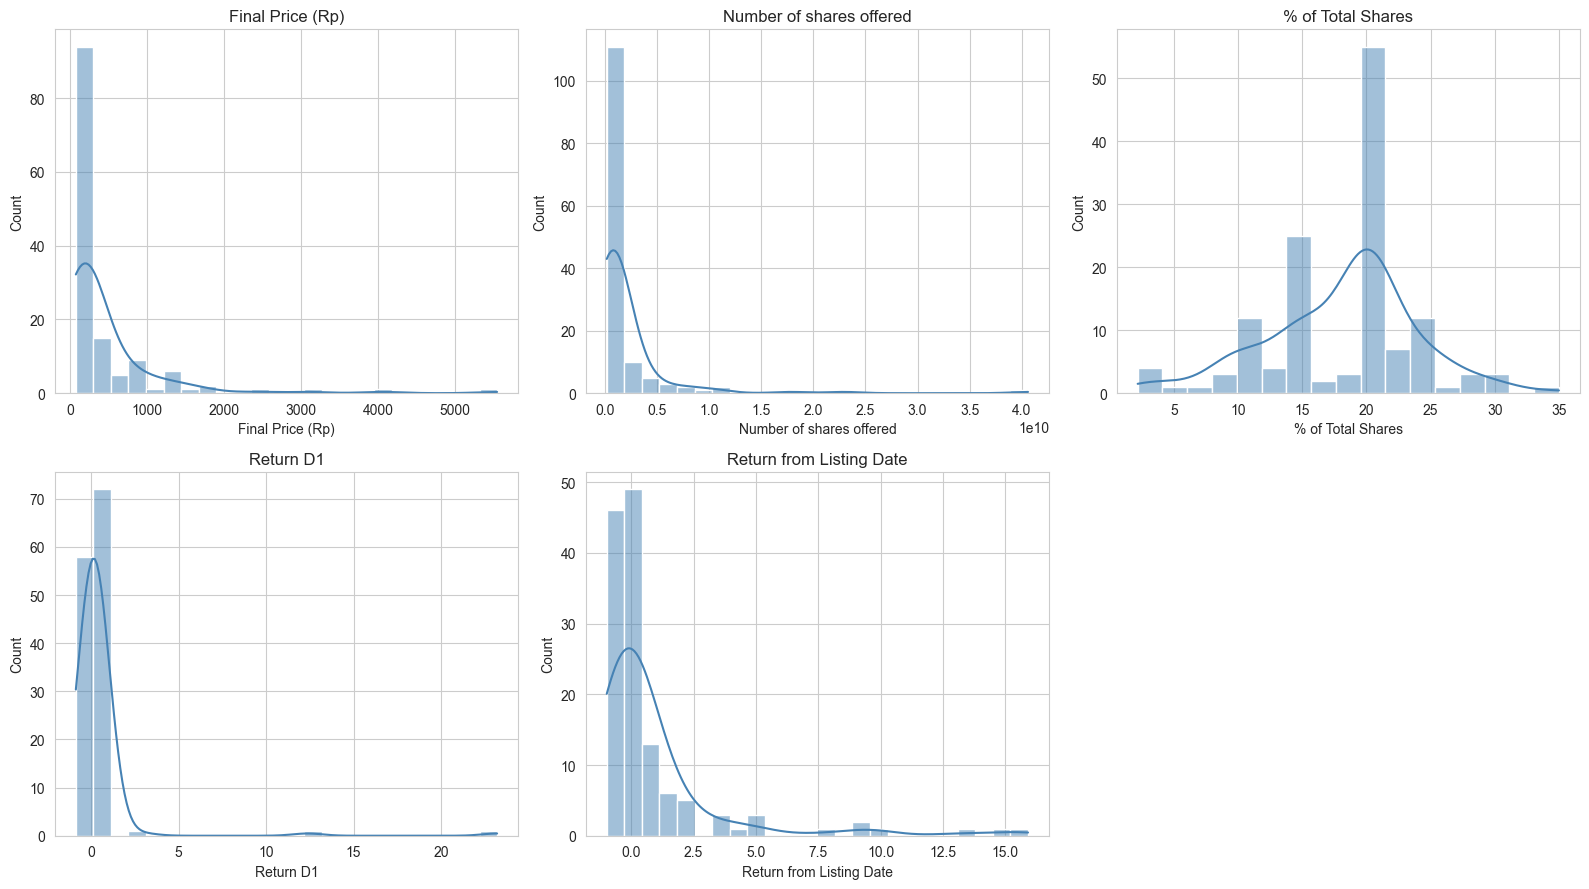

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(col)
axes[-1].axis('off')
plt.tight_layout()
plt.show()

`Final Price (Rp)` terlihat sangat condong ke kanan — mayoritas emiten IPO di harga rendah, kisaran Rp50 sampai Rp200. Ini konsisten dengan karakteristik pasar IPO Indonesia yang didominasi emiten skala kecil-menengah.

`Return D1` juga memiliki beberapa nilai yang jauh dari mayoritas data. Nilai-nilai ekstrem ini dibahas lebih detail di bagian Deteksi Outlier, termasuk cara membedakan nilai ekstrem yang wajar (kena ARA) dari yang berpotensi kesalahan data.

## 6. Analisis Univariat — Variabel Kategorikal

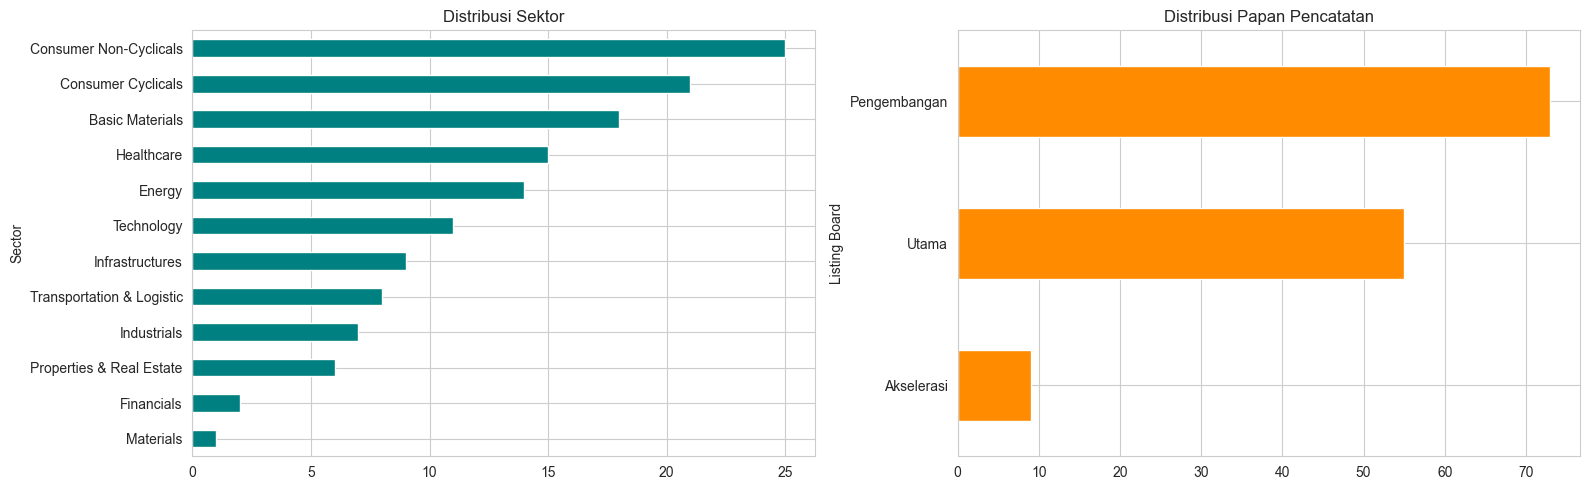

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

df['Sector'].value_counts().plot(kind='barh', ax=axes[0], color='teal')
axes[0].set_title('Distribusi Sektor')
axes[0].invert_yaxis()

df['Listing Board'].value_counts(dropna=False).plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set_title('Distribusi Papan Pencatatan')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

In [12]:
lead_underwriter = df['Participant Admin'].str.split(' - ').str[-1].str.strip()
print(f"Jumlah underwriter unik (lead): {lead_underwriter.nunique()}")
print()
top15 = lead_underwriter.value_counts().head(15)
top15

Jumlah underwriter unik (lead): 34



Participant Admin
UOB KAY HIAN SEKURITAS               17
MANDIRI SEKURITAS                    11
NH KORINDO SEKURITAS INDONESIA        8
MIRAE ASSET SEKURITAS INDONESIA       8
CIPTADANA SEKURITAS ASIA              7
LOTUS ANDALAN SEKURITAS               7
KGI SEKURITAS INDONESIA               6
SUCOR SEKURITAS                       5
BRI DANAREKSA SEKURITAS               5
SURYA FAJAR SEKURITAS                 5
TRIMEGAH SEKURITAS INDONESIA TBK.     5
SAMUEL SEKURITAS INDONESIA            4
PANIN SEKURITAS TBK,                  4
HENAN PUTIHRAI SEKURITAS              4
SHINHAN SEKURITAS INDONESIA           4
Name: count, dtype: int64

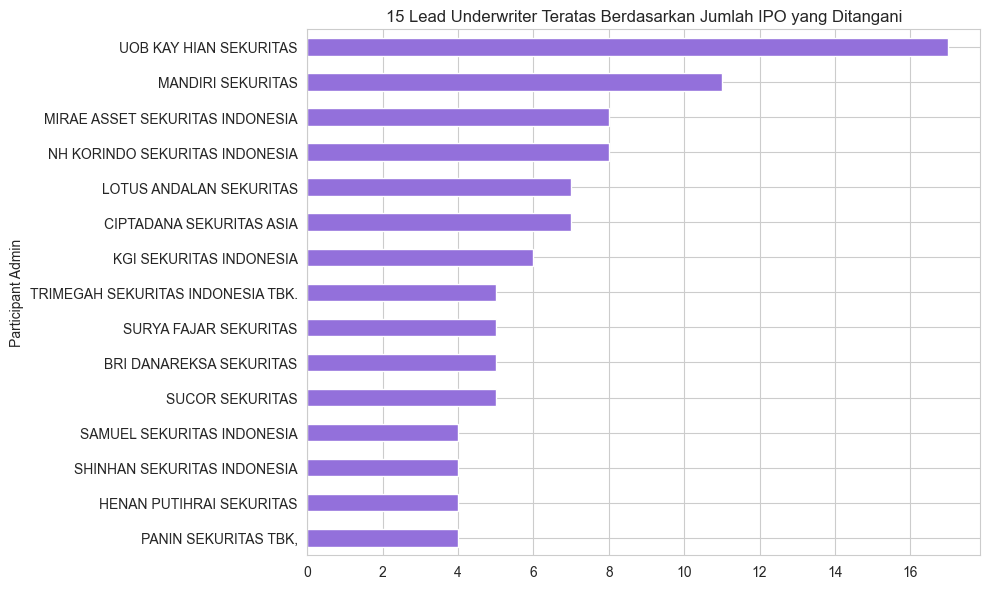

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))
top15.sort_values().plot(kind='barh', ax=ax, color='mediumpurple')
ax.set_title('15 Lead Underwriter Teratas Berdasarkan Jumlah IPO yang Ditangani')
plt.tight_layout()
plt.show()

Terdapat 41 underwriter unik untuk sekitar 240 baris, artinya rata-rata satu underwriter hanya menangani 5–6 IPO. Jika kolom ini dijadikan fitur kategorikal dengan one-hot encoding penuh, hasilnya akan sangat sparse. Rencana di Tahap 2 adalah mengelompokkan menjadi beberapa nama teratas ditambah kategori "Lainnya".

## 7. Analisis Korelasi Awal

Heatmap berikut menampilkan korelasi antar variabel numerik yang tersedia di tahap ini. Perlu dicatat bahwa cakupannya masih terbatas, karena sebagian besar calon fitur penting seperti sektor, underwriter, dan papan pencatatan masih berbentuk kategorikal dan belum di-encode. Korelasi yang lebih lengkap baru bisa dilihat setelah proses encoding di Tahap 2.

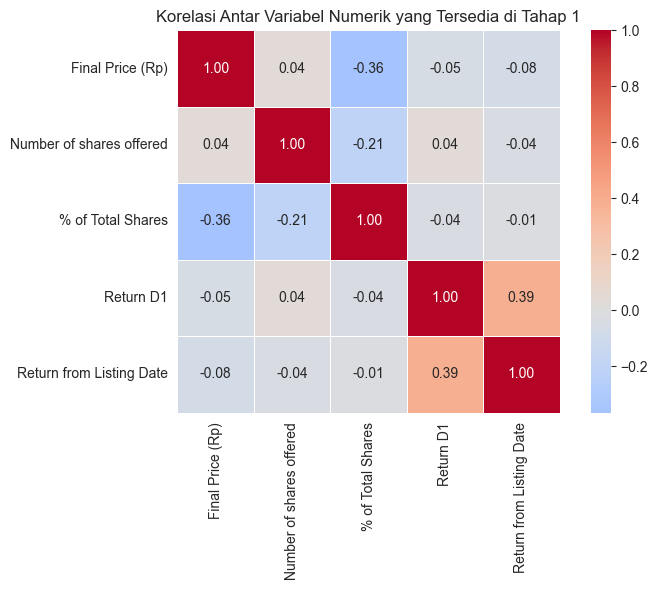

In [14]:
corr_cols = ['Final Price (Rp)', 'Number of shares offered', '% of Total Shares',
             'Return D1', 'Return from Listing Date']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Korelasi Antar Variabel Numerik yang Tersedia di Tahap 1')
plt.tight_layout()
plt.show()

Belum terlihat hubungan yang kuat antar variabel, yang merupakan hal wajar karena variabel numerik yang tersedia sekarang memang bukan variabel yang secara teori paling berkaitan langsung dengan return hari pertama. Fitur yang diduga lebih relevan, seperti posisi harga final terhadap rentang book building atau kategori sektor, belum masuk ke perhitungan ini karena baru akan dibentuk di Tahap 2.

## 8. Deteksi Outlier

Deteksi outlier difokuskan pada `Return D1` sampai `Return D7` karena variabel ini paling kritis dan menjadi dasar target prediksi. Metode IQR digunakan untuk deteksi awal, kemudian dibandingkan dengan batas ARA dan ARB struktural.

Pendekatan ini penting karena untuk data return saham, outlier secara statistik belum tentu berarti data yang salah — bisa saja itu nilai ARA yang memang terjadi berturut-turut secara wajar.

**Keputusan ARB:** Batas ARB ditetapkan flat **-15%** untuk semua papan, mengikuti aturan BEI terbaru yang berlaku sejak April 2025, yang menyeragamkan ARB menjadi 15% untuk Papan Utama, Pengembangan, dan Ekonomi Baru. Pendekatan sadar-tanggal tidak diterapkan karena kompleksitasnya tidak sebanding dengan manfaatnya untuk dataset ini.

In [15]:
def ara_cap(price):
    if pd.isna(price):
        return np.nan
    if price <= 200:
        return 0.35
    elif price <= 5000:
        return 0.25
    else:
        return 0.20

df['ARA_cap'] = df['Final Price (Rp)'].apply(ara_cap)

d_cols = ['Return D1', 'Return D2', 'Return D3', 'Return D4', 'Return D5', 'Return D6', 'Return D7']

# Batas IQR untuk Return D1
q1, q3 = df['Return D1'].quantile([0.25, 0.75])
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
print(f"Batas IQR untuk Return D1: [{lower_bound:.3f}, {upper_bound:.3f}]")

outliers_iqr = df[(df['Return D1'] < lower_bound) | (df['Return D1'] > upper_bound)]
print(f"Jumlah outlier IQR pada Return D1: {len(outliers_iqr)}")

Batas IQR untuk Return D1: [-0.501, 0.851]
Jumlah outlier IQR pada Return D1: 9


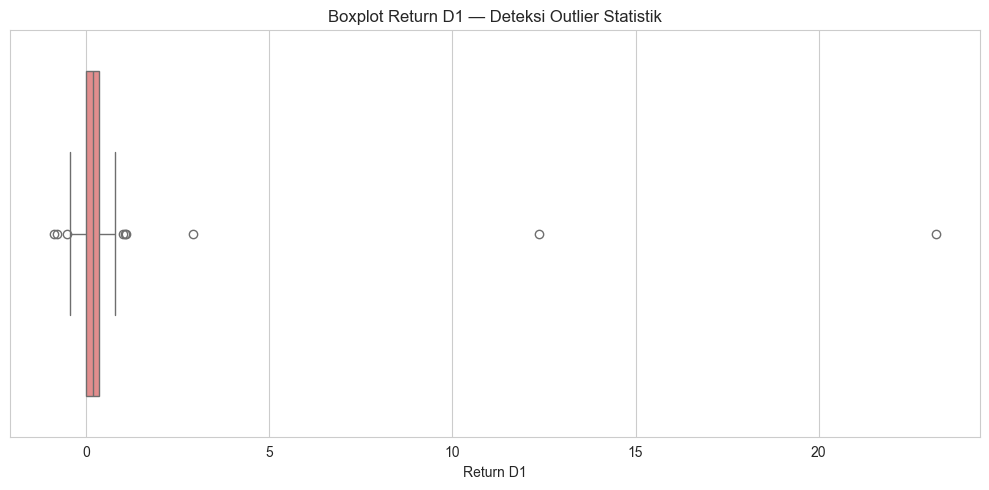

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(x=df['Return D1'], ax=ax, color='lightcoral')
ax.set_title('Boxplot Return D1 — Deteksi Outlier Statistik')
plt.tight_layout()
plt.show()

In [17]:
# ARB flat -15% sesuai aturan BEI terbaru (berlaku sejak April 2025)
ARB_THRESHOLD = -0.15

def classify_d1(row):
    if pd.isna(row['Return D1']) or pd.isna(row['ARA_cap']):
        return np.nan
    if abs(row['ARA_cap'] - row['Return D1']) <= 0.02:
        return 'ARA (di batas cap)'
    elif row['Return D1'] <= ARB_THRESHOLD:
        return 'ARB (turun tajam)'
    else:
        return 'Normal'

df['Status_D1_Struktural'] = df.apply(classify_d1, axis=1)

print("Klasifikasi Return D1 berdasarkan batas ARA/ARB struktural:")
print(df['Status_D1_Struktural'].value_counts(dropna=False))
print()
print("Detail baris yang terklasifikasi ARB:")
arb_rows = df[df['Status_D1_Struktural'] == 'ARB (turun tajam)']
print(arb_rows[['Ticker Code', 'Company Name', 'Final Price (Rp)', 'Return D1']].to_string(index=False))

Klasifikasi Return D1 berdasarkan batas ARA/ARB struktural:
Status_D1_Struktural
Normal                71
ARA (di batas cap)    49
ARB (turun tajam)     13
NaN                    4
Name: count, dtype: int64

Detail baris yang terklasifikasi ARB:
Ticker Code                           Company Name  Final Price (Rp)  Return D1
       KLAS PT Pelayaran Kurnia Lautan Semesta Tbk             146.0  -0.221549
       CUAN            PT Petrindo Jaya Kreasi Tbk             220.0  -0.875455
       HILL                         PT Hillcon Tbk            1250.0  -0.787200
       BUAH          PT Segar Kumala Indonesia Tbk             388.0  -0.376289
       ADCP          PT ADHI COMMUTER PROPERTI TBK             130.0  -0.276923
       WGSH              PT Wira Global Solusi Tbk             140.0  -0.407143
       TAYS              PT JAYA SWARASA AGUNG TBK             360.0  -0.444444
       BOBA      PT Formosa Ingredient Factory Tbk             280.0  -0.285714
       IDEA          PT Idea Indon

## 9. Penanganan Outlier — Keputusan per Target

Karena Tahap 2 akan memiliki dua jenis target yang berbeda, penanganan outlier tidak bisa disamaratakan:

**Target klasifikasi (`Status_D1_Struktural`):** Tidak ada transformasi. `Return D1` digunakan apa adanya karena klasifikasi membutuhkan nilai asli untuk menentukan kelasnya.

**Target regresi (`CumReturn_7D_raw`):** Winsorizing **tidak diterapkan** pada variabel target. Tujuan pemodelan adalah memprediksi return aktual yang akan terjadi di pasar nyata, termasuk untuk kasus seperti JELI (+25%) dan JECX (+24,8%) yang baru listing. Memotong nilai-nilai ini akan merusak kapasitas model untuk membedakan kasus return tinggi dari return moderat.

Return kumulatif 7 hari dihitung menggunakan formula perkalian yang benar, bukan penjumlahan sederhana:

In [18]:
def cum_return_7d(row):
    vals = row[d_cols].values.astype(float)
    if np.isnan(vals).any():
        return np.nan
    return np.prod(1 + vals) - 1

df['CumReturn_7D_raw'] = df.apply(cum_return_7d, axis=1)
valid_mask = df['CumReturn_7D_raw'].notna()

print(f"Baris dengan data return 7 hari lengkap: {df['CumReturn_7D_raw'].notna().sum()}")
print()
print("Statistik CumReturn_7D_raw:")
print(df.loc[valid_mask, 'CumReturn_7D_raw'].describe().round(4))

Baris dengan data return 7 hari lengkap: 131

Statistik CumReturn_7D_raw:
count    131.0000
mean       0.6752
std        2.4883
min       -0.7376
25%       -0.1167
50%        0.1121
75%        0.6876
max       23.6000
Name: CumReturn_7D_raw, dtype: float64


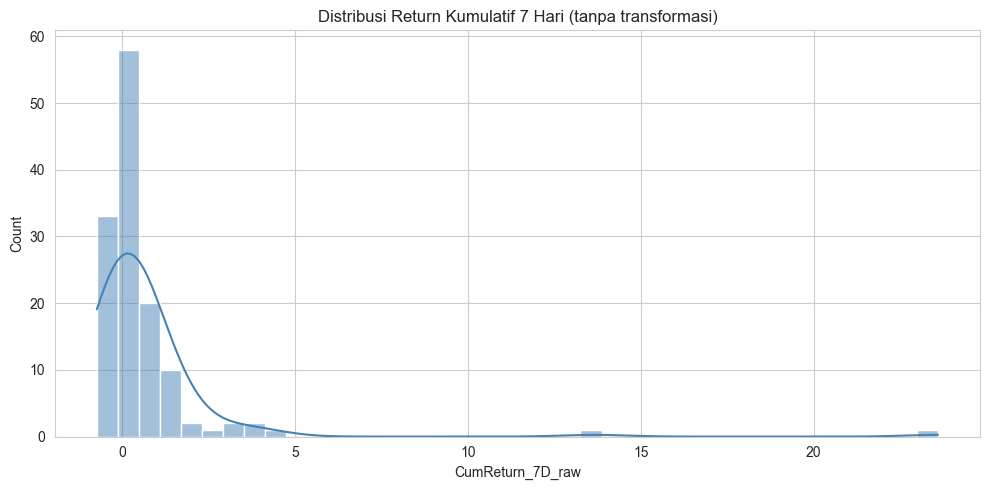

In [19]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df.loc[valid_mask, 'CumReturn_7D_raw'], kde=True, ax=ax, color='steelblue', bins=40)
ax.set_title('Distribusi Return Kumulatif 7 Hari (tanpa transformasi)')
ax.set_xlabel('CumReturn_7D_raw')
plt.tight_layout()
plt.show()

Distribusi return kumulatif 7 hari memang right-skewed dan memiliki ekor panjang ke kanan. Ini adalah karakteristik yang wajar dan harus dipertahankan apa adanya. Model yang dilatih dengan data ini diharapkan dapat menangkap variasi tersebut, bukan mengabaikannya.

## 10. Ringkasan Tahap 1 dan Dataset Antara

Dataset hasil Tahap 1 disimpan sebagai `dataset_tahap1_bersih.csv` untuk dilanjutkan ke Tahap 2 — feature engineering dan pemodelan.

In [20]:
print("Ringkasan Tahap 1")
print(f"Jumlah baris awal (raw)              : {pd.read_csv(DATA_PATH).shape[0]}")
print(f"Jumlah baris setelah semua penanganan: {df.shape[0]}")
print(f"Jumlah kolom akhir                   : {df.shape[1]}")
print()
print("Enam emiten target masih ada di dataset:")
print(df[df['Ticker Code'].isin(target_tickers)]['Ticker Code'].tolist())
print()

# Verifikasi Listing Board 6 emiten terisi
print("Listing Board 6 emiten target:")
print(df[df['Ticker Code'].isin(target_tickers)][['Ticker Code', 'Listing Board']].to_string(index=False))

df.to_csv('dataset_tahap1_bersih.csv', index=False)
print("\nTersimpan sebagai dataset_tahap1_bersih.csv")

Ringkasan Tahap 1
Jumlah baris awal (raw)              : 251
Jumlah baris setelah semua penanganan: 137
Jumlah kolom akhir                   : 32

Enam emiten target masih ada di dataset:
['PRDL', 'EMMI', 'BACH', 'JELI', 'JECX', 'RANS']

Listing Board 6 emiten target:
Ticker Code Listing Board
       PRDL  Pengembangan
       EMMI  Pengembangan
       BACH         Utama
       JELI  Pengembangan
       JECX         Utama
       RANS  Pengembangan

Tersimpan sebagai dataset_tahap1_bersih.csv


**Keputusan yang telah difinalisasi di Tahap 1:**

1. **ARB:** Ditetapkan flat **-15%** untuk semua papan sesuai aturan BEI terbaru (April 2025). Pendekatan sadar-tanggal tidak diterapkan.
2. **Listing Board:** Dipertahankan sebagai fitur. Nilai kosong untuk 6 emiten target diisi manual; baris historis lain yang kosong di-drop.
3. **Winsorizing target regresi:** Tidak diterapkan. `CumReturn_7D_raw` digunakan langsung agar nilai aktual pasar tetap terjaga.
4. **Underwriter:** Masih dalam bentuk asli; pengelompokan kategori sparse akan dilakukan di Tahap 2.

**Yang menunggu di Tahap 2:** encoding fitur kategorikal, feature engineering (posisi harga vs rentang book building, umur perusahaan, dll), pemilihan model, dan evaluasi.

---

# Tahap 2: Feature Engineering, Pemodelan, dan Evaluasi

Tahap ini melanjutkan langsung dari dataset bersih yang dihasilkan Tahap 1. Fokusnya adalah:
1. **Feature engineering** — membentuk fitur-fitur yang secara teori maupun empiris relevan terhadap return IPO
2. **Pemodelan klasifikasi** — Logistic Regression untuk memprediksi status Return D1 (ARA / Normal / ARB)
3. **Pemodelan regresi** — Linear Regression untuk memprediksi return kumulatif 7 hari
4. **Evaluasi** — metrik, interpretasi koefisien, dan prediksi untuk 6 emiten target

Dataset yang digunakan adalah `df` yang telah diproses di Tahap 1. Jika notebook dijalankan ulang dari awal, pastikan seluruh sel Tahap 1 sudah dieksekusi terlebih dahulu sebelum menjalankan sel di bawah ini.

## 11. Feature Engineering

Fitur-fitur baru dibentuk dari kolom yang sudah tersedia, dengan fokus pada variabel yang secara teori maupun literatur IPO terbukti relevan terhadap underpricing dan return jangka pendek.

In [21]:
from sklearn.preprocessing import LabelEncoder

# ── 11.1 Posisi harga final terhadap rentang book building ──
# Mengukur seberapa "tinggi" harga final ditetapkan dalam rentang yang diumumkan.
# Nilai 1.0 = di batas atas, 0.0 = di batas bawah, >1.0 = di atas rentang.
# Fitur ini merupakan proksi sentimen permintaan saat book building.

df['BB_position'] = (
    (df['Final Price (Rp)'] - df['Lowest Book Building Price (Rp)']) /
    (df['Highest Book Building Price (Rp)'] - df['Lowest Book Building Price (Rp)'])
).clip(0, 1)

print("BB_position — statistik:")
print(df['BB_position'].describe().round(3))
print(f"Nilai null: {df['BB_position'].isna().sum()}")

BB_position — statistik:
count    137.000
mean       0.541
std        0.414
min        0.000
25%        0.000
50%        0.580
75%        1.000
max        1.000
Name: BB_position, dtype: float64
Nilai null: 0


In [22]:
# ── 11.2 Log harga IPO ──
# Harga IPO memiliki distribusi right-skewed ekstrem.
# Transformasi log menghasilkan distribusi lebih simetris dan mengurangi
# pengaruh leverage dari emiten berharga sangat tinggi.

df['log_price'] = np.log1p(df['Final Price (Rp)'])

# ── 11.3 Log proceed ──
# Proceed = total dana yang dihimpun dari IPO.
# Emiten dengan proceed besar cenderung lebih dikenal investor
# sehingga minat pembelian lebih terukur dan underpricing lebih rendah.

df['proceed'] = df['Final Price (Rp)'] * df['Number of shares offered']
df['log_proceed'] = np.log1p(df['proceed'])

print("Fitur log berhasil dibuat:")
print(df[['Final Price (Rp)', 'log_price', 'proceed', 'log_proceed']].describe().round(2))

Fitur log berhasil dibuat:
       Final Price (Rp)  log_price       proceed  log_proceed
count            137.00     137.00  1.370000e+02       137.00
mean             451.15       5.57  9.987760e+11        26.12
std              712.40       0.91  2.647054e+12         1.51
min               75.00       4.33  2.025000e+10        23.73
25%              125.00       4.84  7.380000e+10        25.02
50%              200.00       5.30  1.790000e+11        25.91
75%              442.00       6.09  4.312500e+11        26.79
max             5550.00       8.62  1.833641e+13        30.54


In [23]:
# ── 11.4 Encoding Listing Board ──
# Papan Utama = 1, Papan Pengembangan = 0
# Encoding biner lebih tepat dari label encoding karena hanya ada 2 nilai.

board_map = {'Utama': 1, 'Pengembangan': 0}
df['listing_board_enc'] = df['Listing Board'].map(board_map)

print("Distribusi listing_board_enc:")
print(df['listing_board_enc'].value_counts())

Distribusi listing_board_enc:
listing_board_enc
0.0    73
1.0    55
Name: count, dtype: int64


In [24]:
# ── 11.5 Encoding Sektor ──
# One-hot encoding untuk sektor karena tidak ada urutan alami antar kategori.
# drop_first=True untuk menghindari multikolinearitas (dummy variable trap).

sector_dummies = pd.get_dummies(df['Sector'], prefix='sektor', drop_first=True)
df = pd.concat([df, sector_dummies], axis=1)

print(f"Kolom sektor yang dibuat: {sector_dummies.columns.tolist()}")
print(f"Shape setelah encoding sektor: {df.shape}")

Kolom sektor yang dibuat: ['sektor_Consumer Cyclicals', 'sektor_Consumer Non-Cyclicals', 'sektor_Energy', 'sektor_Financials', 'sektor_Healthcare', 'sektor_Industrials', 'sektor_Infrastructures', 'sektor_Materials', 'sektor_Properties & Real Estate', 'sektor_Technology', 'sektor_Transportation & Logistic']
Shape setelah encoding sektor: (137, 48)


In [25]:
# ── 11.6 Encoding Underwriter ──
# 41 underwriter unik — terlalu sparse untuk one-hot encoding penuh.
# Strategi: top 10 underwriter berdasarkan frekuensi dipertahankan,
# sisanya dikelompokkan menjadi 'Lainnya'.

lead_uw = df['Participant Admin'].str.split(' - ').str[-1].str.strip()
df['lead_underwriter'] = lead_uw

top10_uw = lead_uw.value_counts().head(10).index.tolist()
df['underwriter_grouped'] = df['lead_underwriter'].apply(
    lambda x: x if x in top10_uw else 'Lainnya'
)

uw_dummies = pd.get_dummies(df['underwriter_grouped'], prefix='uw', drop_first=True)
df = pd.concat([df, uw_dummies], axis=1)

print(f"Underwriter unik setelah grouping: {df['underwriter_grouped'].nunique()}")
print(f"Kolom underwriter yang dibuat: {len(uw_dummies.columns)}")
print(f"Shape setelah encoding underwriter: {df.shape}")

Underwriter unik setelah grouping: 11
Kolom underwriter yang dibuat: 10
Shape setelah encoding underwriter: (137, 60)


In [26]:
# ── 11.7 Ringkasan fitur yang tersedia untuk pemodelan ──

feature_cols = (
    ['BB_position', 'log_price', 'log_proceed', '% of Total Shares',
     'listing_board_enc']
    + [c for c in df.columns if c.startswith('sektor_')]
    + [c for c in df.columns if c.startswith('uw_')]
)

print(f"Total fitur untuk pemodelan: {len(feature_cols)}")
print()
print("Daftar fitur:")
for f in feature_cols:
    null_n = df[f].isna().sum()
    print(f"  {f:<40} null: {null_n}")

Total fitur untuk pemodelan: 26

Daftar fitur:
  BB_position                              null: 0
  log_price                                null: 0
  log_proceed                              null: 0
  % of Total Shares                        null: 0
  listing_board_enc                        null: 9
  sektor_Consumer Cyclicals                null: 0
  sektor_Consumer Non-Cyclicals            null: 0
  sektor_Energy                            null: 0
  sektor_Financials                        null: 0
  sektor_Healthcare                        null: 0
  sektor_Industrials                       null: 0
  sektor_Infrastructures                   null: 0
  sektor_Materials                         null: 0
  sektor_Properties & Real Estate          null: 0
  sektor_Technology                        null: 0
  sektor_Transportation & Logistic         null: 0
  uw_CIPTADANA SEKURITAS ASIA              null: 0
  uw_KGI SEKURITAS INDONESIA               null: 0
  uw_LOTUS ANDALAN SEKURITAS       

In [27]:
df.to_csv('dataset_tahap1_bersih.csv', index=False)

## 12. Persiapan Data untuk Pemodelan

Dataset dibagi menjadi tiga subset dengan urutan yang ketat untuk menghindari data leakage:

1. **Train set (80%)** — digunakan untuk melatih model
2. **Validation set (20%)** — digunakan untuk mengevaluasi dan memilih model terbaik
3. **Test set (6 emiten target)** — digunakan untuk prediksi akhir; tidak pernah disentuh selama proses pelatihan maupun seleksi model

**Prinsip utama pipeline preprocessing ini:** `SimpleImputer` dan `StandardScaler` hanya di-fit pada train set, kemudian hasilnya di-transform ke validation set dan test set secara terpisah. Ini mencegah informasi dari validation dan test set "bocor" ke proses pelatihan — penyebab utama data leakage yang menghasilkan performa evaluasi yang terlalu optimis.

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

target_tickers = ['RANS', 'PRDL', 'BACH', 'JECX', 'EMMI', 'JELI']

# ── Step 1: Pisahkan test set (6 emiten target) ──────────────────────────────
pred_df = df[df['Ticker Code'].isin(target_tickers)].copy()

# ── Step 2: Sisanya jadi pool untuk train + validation ───────────────────────
pool_df = df[
    (df['IPO Status'] == 'Closed') &
    df['Return D1'].notna() &
    ~df['Ticker Code'].isin(target_tickers)
].copy()

print(f"Pool (train + val) : {len(pool_df)} emiten")
print(f"Test set (prediksi): {len(pred_df)} emiten — {pred_df['Ticker Code'].tolist()}")

Pool (train + val) : 131 emiten
Test set (prediksi): 6 emiten — ['PRDL', 'EMMI', 'BACH', 'JELI', 'JECX', 'RANS']


In [29]:
# ── Step 3: Label target ─────────────────────────────────────────────────────
# Klasifikasi
y_pool_clf = pool_df['Status_D1_Struktural'].fillna('Normal')

# Regresi (hanya baris yang punya data return D1-D7 lengkap)
pool_reg = pool_df[pool_df['CumReturn_7D_raw'].notna()].copy()
y_pool_reg = pool_reg['CumReturn_7D_raw']

print("Distribusi label klasifikasi (pool):")
print(y_pool_clf.value_counts())
print(f"\nPool regresi: {len(pool_reg)} emiten")

Distribusi label klasifikasi (pool):
Status_D1_Struktural
Normal                71
ARA (di batas cap)    47
ARB (turun tajam)     13
Name: count, dtype: int64

Pool regresi: 131 emiten


In [30]:
# ── Step 4: Split 80/20 (stratified untuk klasifikasi) ───────────────────────
X_pool_clf = pool_df[feature_cols]
X_train_clf_raw, X_val_clf_raw, y_train_clf, y_val_clf = train_test_split(
    X_pool_clf, y_pool_clf,
    test_size=0.2,
    random_state=42,
    stratify=y_pool_clf
)

X_pool_reg = pool_reg[feature_cols]
X_train_reg_raw, X_val_reg_raw, y_train_reg, y_val_reg = train_test_split(
    X_pool_reg, y_pool_reg,
    test_size=0.2,
    random_state=42
)

print(f"Klasifikasi — Train: {len(X_train_clf_raw)} | Val: {len(X_val_clf_raw)}")
print(f"Regresi     — Train: {len(X_train_reg_raw)} | Val: {len(X_val_reg_raw)}")
print(f"\nDistribusi label train:")
print(y_train_clf.value_counts())
print(f"\nDistribusi label val:")
print(y_val_clf.value_counts())

Klasifikasi — Train: 104 | Val: 27
Regresi     — Train: 104 | Val: 27

Distribusi label train:
Status_D1_Struktural
Normal                57
ARA (di batas cap)    37
ARB (turun tajam)     10
Name: count, dtype: int64

Distribusi label val:
Status_D1_Struktural
Normal                14
ARA (di batas cap)    10
ARB (turun tajam)      3
Name: count, dtype: int64


In [31]:
# ── Step 5: Fit imputer dan scaler HANYA pada train set ──────────────────────
# Klasifikasi
imputer_clf = SimpleImputer(strategy='median')
scaler_clf  = StandardScaler()

X_train_clf = scaler_clf.fit_transform(imputer_clf.fit_transform(X_train_clf_raw))
X_val_clf   = scaler_clf.transform(imputer_clf.transform(X_val_clf_raw))
X_pred_clf  = scaler_clf.transform(imputer_clf.transform(pred_df[feature_cols]))

# Regresi
imputer_reg = SimpleImputer(strategy='median')
scaler_reg  = StandardScaler()

X_train_reg = scaler_reg.fit_transform(imputer_reg.fit_transform(X_train_reg_raw))
X_val_reg   = scaler_reg.transform(imputer_reg.transform(X_val_reg_raw))
X_pred_reg  = scaler_reg.transform(imputer_reg.transform(pred_df[feature_cols]))

print("Pipeline preprocessing selesai.")
print(f"  X_train_clf : {X_train_clf.shape}")
print(f"  X_val_clf   : {X_val_clf.shape}")
print(f"  X_pred_clf  : {X_pred_clf.shape}")
print(f"  X_train_reg : {X_train_reg.shape}")
print(f"  X_val_reg   : {X_val_reg.shape}")

Pipeline preprocessing selesai.
  X_train_clf : (104, 26)
  X_val_clf   : (27, 26)
  X_pred_clf  : (6, 26)
  X_train_reg : (104, 26)
  X_val_reg   : (27, 26)


## 13. Perbandingan Model Klasifikasi

Tiga model dilatih pada train set dan dievaluasi pada validation set yang bersih. Evaluasi pada validation set memberikan gambaran performa yang jujur karena model belum pernah melihat data tersebut.

Model yang dibandingkan:
- **Logistic Regression** — baseline, interpretable
- **Random Forest** — ensemble bagging
- **Gradient Boosting** — ensemble boosting, kandidat model terpilih berdasarkan eksplorasi awal

In [32]:
from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics         import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import StratifiedKFold, cross_val_score

models_clf = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, max_depth=5,
        min_samples_leaf=2, class_weight='balanced', random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100, learning_rate=0.1,
        max_depth=3, random_state=42),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

print(f"{'Model':<25} {'CV F1 Macro':>12} {'Std':>8} {'Val F1 Macro':>14}")
print("-" * 62)

fitted_clf = {}
val_scores = {}

for name, model in models_clf.items():
    # Cross-validation pada train set
    cv_f1 = cross_val_score(model, X_train_clf, y_train_clf,
                            cv=cv, scoring='f1_macro')
    cv_results[name] = cv_f1

    # Fit pada train set
    model.fit(X_train_clf, y_train_clf)
    fitted_clf[name] = model

    # Evaluasi pada validation set
    y_pred_val = model.predict(X_val_clf)
    from sklearn.metrics import f1_score
    val_f1 = f1_score(y_val_clf, y_pred_val, average='macro', zero_division=0)
    val_scores[name] = val_f1

    print(f"{name:<25} {cv_f1.mean():>12.3f} {cv_f1.std():>8.3f} {val_f1:>14.3f}")

Model                      CV F1 Macro      Std   Val F1 Macro
--------------------------------------------------------------
Logistic Regression              0.429    0.050          0.312
Random Forest                    0.465    0.115          0.249
Gradient Boosting                0.383    0.121          0.349


In [33]:
# Classification report per model pada validation set
for name, model in fitted_clf.items():
    y_pred_val = model.predict(X_val_clf)
    print(f"=== {name} — Validation Set ===")
    print(classification_report(y_val_clf, y_pred_val, zero_division=0))
    print()

=== Logistic Regression — Validation Set ===
                    precision    recall  f1-score   support

ARA (di batas cap)       0.40      0.60      0.48        10
 ARB (turun tajam)       0.00      0.00      0.00         3
            Normal       0.62      0.36      0.45        14

          accuracy                           0.41        27
         macro avg       0.34      0.32      0.31        27
      weighted avg       0.47      0.41      0.41        27


=== Random Forest — Validation Set ===
                    precision    recall  f1-score   support

ARA (di batas cap)       0.27      0.30      0.29        10
 ARB (turun tajam)       0.00      0.00      0.00         3
            Normal       0.50      0.43      0.46        14

          accuracy                           0.33        27
         macro avg       0.26      0.24      0.25        27
      weighted avg       0.36      0.33      0.35        27


=== Gradient Boosting — Validation Set ===
                    preci

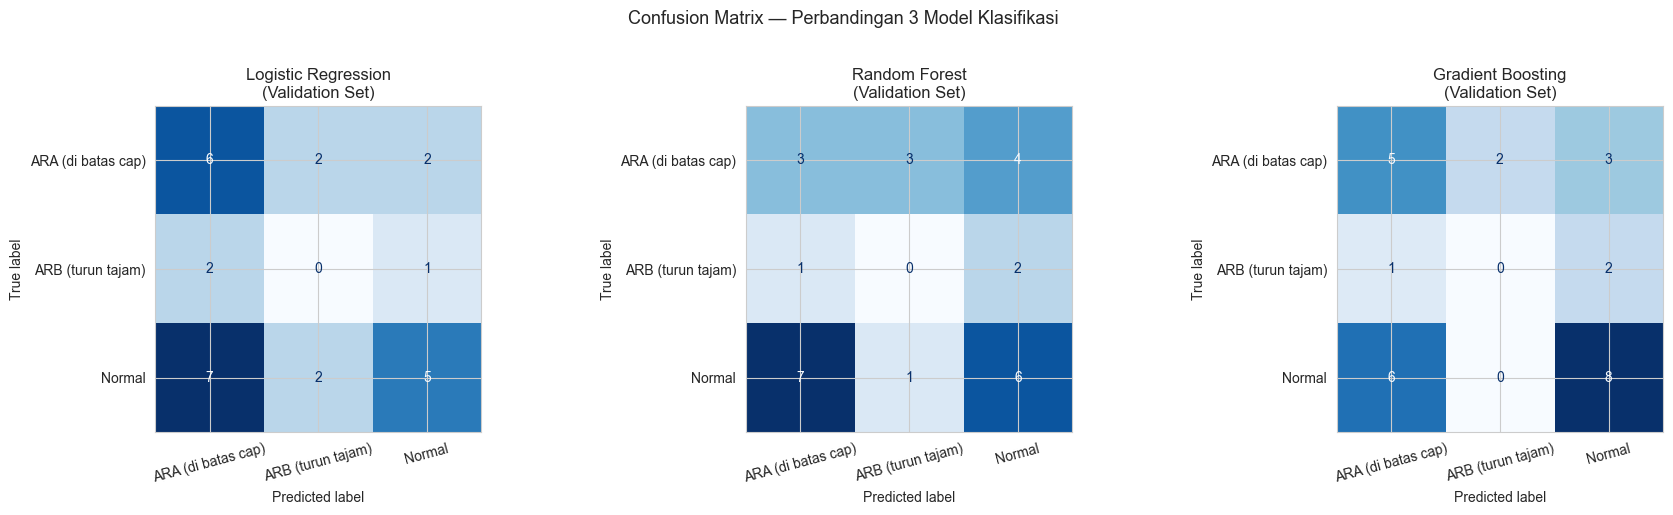

In [34]:
# Confusion matrix 3 model pada validation set
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
class_names = sorted(y_pool_clf.unique())

for ax, (name, model) in zip(axes, fitted_clf.items()):
    y_pred_val = model.predict(X_val_clf)
    cm = confusion_matrix(y_val_clf, y_pred_val, labels=class_names)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\n(Validation Set)')
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Confusion Matrix — Perbandingan 3 Model Klasifikasi', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

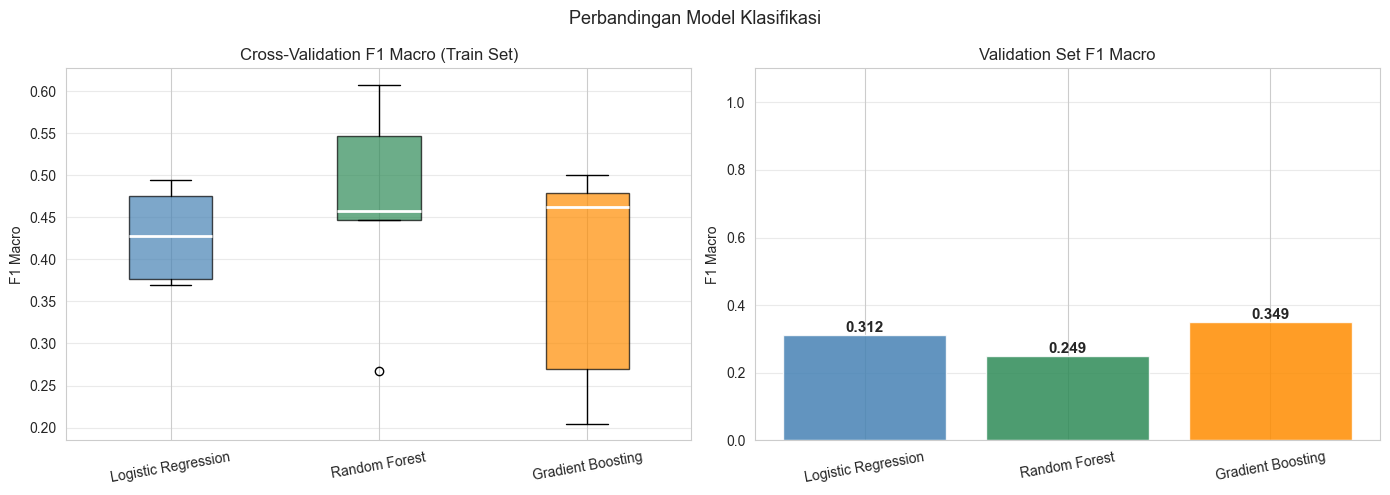


Model klasifikasi terpilih: Gradient Boosting (Val F1 Macro = 0.349)


In [35]:
# Visualisasi perbandingan CV F1 dan Val F1
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# CV scores
ax = axes[0]
for i, (name, scores) in enumerate(cv_results.items()):
    ax.boxplot(scores, positions=[i], widths=0.4,
               patch_artist=True,
               boxprops=dict(facecolor=['steelblue','seagreen','darkorange'][i], alpha=0.7),
               medianprops=dict(color='white', lw=2))
ax.set_xticks(range(3))
ax.set_xticklabels(models_clf.keys(), rotation=10)
ax.set_ylabel('F1 Macro')
ax.set_title('Cross-Validation F1 Macro (Train Set)')
ax.grid(axis='y', alpha=0.4)

# Val F1
ax2 = axes[1]
names = list(val_scores.keys())
scores_list = list(val_scores.values())
colors = ['steelblue', 'seagreen', 'darkorange']
bars = ax2.bar(names, scores_list, color=colors, alpha=0.85)
for bar, val in zip(bars, scores_list):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 0.01,
             f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')
ax2.set_ylim(0, 1.1)
ax2.set_ylabel('F1 Macro')
ax2.set_title('Validation Set F1 Macro')
ax2.tick_params(axis='x', rotation=10)
ax2.grid(axis='y', alpha=0.4)

plt.suptitle('Perbandingan Model Klasifikasi', fontsize=13)
plt.tight_layout()
plt.show()

best_clf_name = max(val_scores, key=val_scores.get)
print(f"\nModel klasifikasi terpilih: {best_clf_name} (Val F1 Macro = {val_scores[best_clf_name]:.3f})")

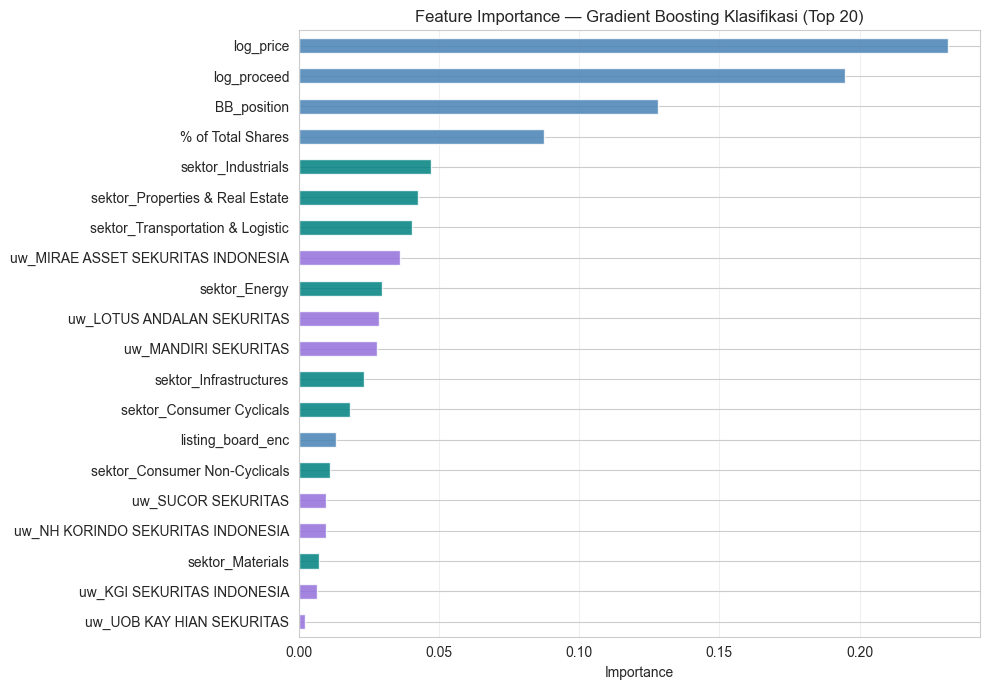

In [36]:
# Feature importance model terpilih (Gradient Boosting)
best_clf = fitted_clf['Gradient Boosting']

importance_clf = pd.Series(
    best_clf.feature_importances_,
    index=feature_cols
).sort_values(ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['steelblue' if f in ['BB_position','log_price','log_proceed',
          '% of Total Shares','listing_board_enc']
          else ('teal' if 'sektor' in f else 'mediumpurple')
          for f in importance_clf.index]
importance_clf.plot(kind='barh', ax=ax, color=colors, alpha=0.85)
ax.set_title('Feature Importance — Gradient Boosting Klasifikasi (Top 20)')
ax.set_xlabel('Importance')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 14. Perbandingan Model Regresi

Dua model dilatih pada train set dan dievaluasi pada validation set. Metrik utama: R² (seberapa besar variansi yang bisa dijelaskan model) dan MAE (rata-rata kesalahan prediksi absolut).

Model yang dibandingkan:
- **Linear Regression** — baseline
- **Random Forest Regressor** — kandidat model terpilih berdasarkan eksplorasi awal

In [37]:
from sklearn.linear_model  import LinearRegression
from sklearn.ensemble      import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics       import mean_absolute_error, r2_score

models_reg = {
    'Linear Regression': LinearRegression(),
    'Random Forest'    : RandomForestRegressor(
        n_estimators=100, max_depth=6,
        min_samples_leaf=2, random_state=42),
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_results_reg = {}

print(f"{'Model':<22} {'CV R² Mean':>12} {'CV R² Std':>10} {'Val R²':>10} {'Val MAE':>10}")
print("-" * 67)

fitted_reg = {}
val_reg_scores = {}

for name, model in models_reg.items():
    # CV pada train set
    cv_r2 = cross_val_score(model, X_train_reg, y_train_reg, cv=kf, scoring='r2')
    cv_results_reg[name] = cv_r2

    # Fit pada train set
    model.fit(X_train_reg, y_train_reg)
    fitted_reg[name] = model

    # Evaluasi pada validation set
    y_pred_val = model.predict(X_val_reg)
    val_r2  = r2_score(y_val_reg, y_pred_val)
    val_mae = mean_absolute_error(y_val_reg, y_pred_val)
    val_reg_scores[name] = {'r2': val_r2, 'mae': val_mae}

    print(f"{name:<22} {cv_r2.mean():>12.3f} {cv_r2.std():>10.3f} {val_r2:>10.3f} {val_mae:>10.3f}")

Model                    CV R² Mean  CV R² Std     Val R²    Val MAE
-------------------------------------------------------------------
Linear Regression            -4.522      2.964     -4.150      1.296
Random Forest                -2.139      2.335     -1.637      0.981


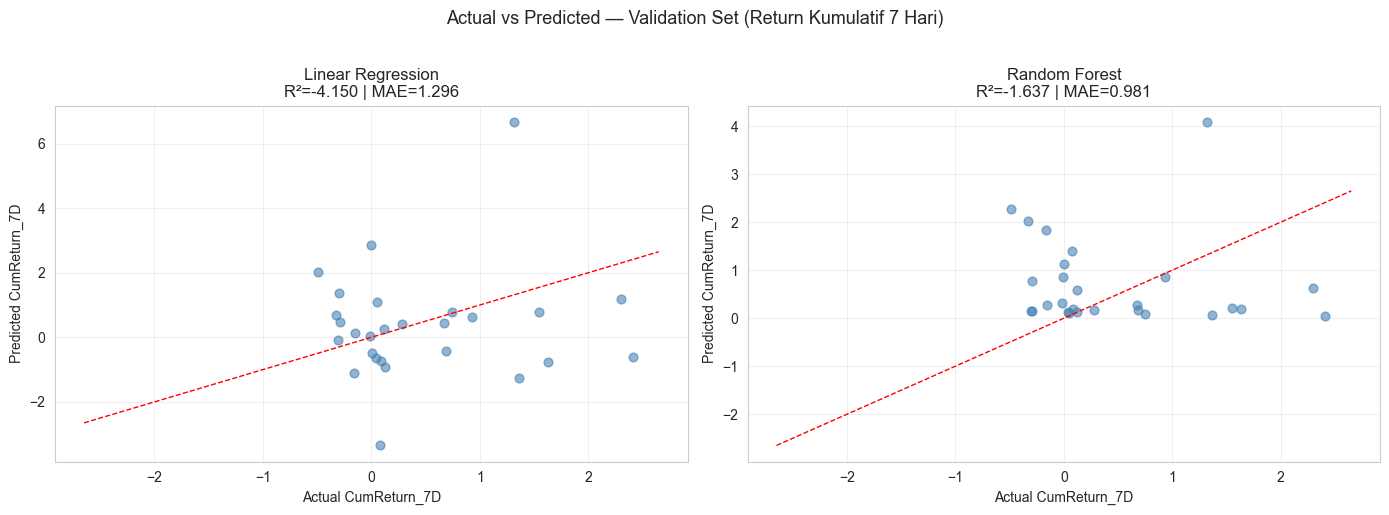


Model regresi terpilih: Random Forest (Val R² = -1.637, MAE = 0.981)


In [38]:
# Actual vs Predicted pada validation set — 2 model
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, model) in zip(axes, fitted_reg.items()):
    y_pred_val = model.predict(X_val_reg)
    r2  = r2_score(y_val_reg, y_pred_val)
    mae = mean_absolute_error(y_val_reg, y_pred_val)

    ax.scatter(y_val_reg, y_pred_val, alpha=0.6, s=40, color='steelblue')
    lim = max(abs(y_val_reg.max()), abs(y_val_reg.min())) * 1.1
    ax.plot([-lim, lim], [-lim, lim], 'r--', lw=1)
    ax.set_xlabel('Actual CumReturn_7D')
    ax.set_ylabel('Predicted CumReturn_7D')
    ax.set_title(f'{name}\nR²={r2:.3f} | MAE={mae:.3f}')
    ax.grid(True, alpha=0.3)

plt.suptitle('Actual vs Predicted — Validation Set (Return Kumulatif 7 Hari)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

best_reg_name = max(val_reg_scores, key=lambda k: val_reg_scores[k]['r2'])
print(f"\nModel regresi terpilih: {best_reg_name} (Val R² = {val_reg_scores[best_reg_name]['r2']:.3f}, MAE = {val_reg_scores[best_reg_name]['mae']:.3f})")

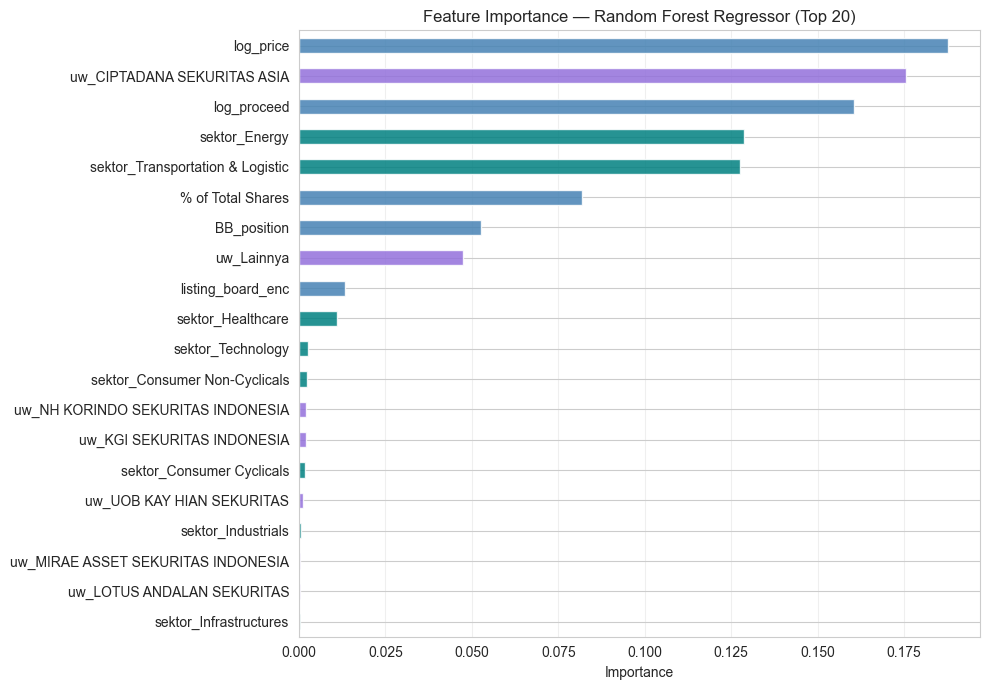

In [39]:
# Feature importance RF Regressor
rf_reg = fitted_reg['Random Forest']

importance_reg = pd.Series(
    rf_reg.feature_importances_,
    index=feature_cols
).sort_values(ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['steelblue' if f in ['BB_position','log_price','log_proceed',
          '% of Total Shares','listing_board_enc']
          else ('teal' if 'sektor' in f else 'mediumpurple')
          for f in importance_reg.index]
importance_reg.plot(kind='barh', ax=ax, color=colors, alpha=0.85)
ax.set_title('Feature Importance — Random Forest Regressor (Top 20)')
ax.set_xlabel('Importance')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 15. Prediksi untuk 6 Emiten Target Juli 2026

Model terpilih (Gradient Boosting untuk klasifikasi, Random Forest untuk regresi) diaplikasikan ke test set — 6 emiten yang akan IPO Juli 2026. Ini adalah prediksi out-of-sample sejati karena data test set tidak pernah disentuh selama proses pelatihan maupun seleksi model.

In [40]:
# Refit model terpilih pada SELURUH pool data (train + val) untuk prediksi final
# Logika: setelah model dipilih menggunakan validation set,
# refit pada seluruh data yang tersedia agar model lebih kuat untuk prediksi

imputer_final_clf = SimpleImputer(strategy='median')
scaler_final_clf  = StandardScaler()
X_pool_clf_proc   = scaler_final_clf.fit_transform(
    imputer_final_clf.fit_transform(pool_df[feature_cols]))
y_pool_clf_full   = pool_df['Status_D1_Struktural'].fillna('Normal')

imputer_final_reg = SimpleImputer(strategy='median')
scaler_final_reg  = StandardScaler()
X_pool_reg_proc   = scaler_final_reg.fit_transform(
    imputer_final_reg.fit_transform(pool_reg[feature_cols]))
y_pool_reg_full   = pool_reg['CumReturn_7D_raw']

# Final models
final_clf = GradientBoostingClassifier(
    n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
final_clf.fit(X_pool_clf_proc, y_pool_clf_full)

final_reg = RandomForestRegressor(
    n_estimators=100, max_depth=6, min_samples_leaf=2, random_state=42)
final_reg.fit(X_pool_reg_proc, y_pool_reg_full)

# Transform test set menggunakan final preprocessors
X_test_clf = scaler_final_clf.transform(
    imputer_final_clf.transform(pred_df[feature_cols]))
X_test_reg = scaler_final_reg.transform(
    imputer_final_reg.transform(pred_df[feature_cols]))

print("Model final berhasil dilatih pada seluruh pool data.")
print(f"  Train pool klasifikasi : {len(X_pool_clf_proc)} emiten")
print(f"  Train pool regresi     : {len(X_pool_reg_proc)} emiten")

Model final berhasil dilatih pada seluruh pool data.
  Train pool klasifikasi : 131 emiten
  Train pool regresi     : 131 emiten


In [41]:
# Prediksi klasifikasi
pred_classes = final_clf.predict(X_test_clf)
pred_proba   = final_clf.predict_proba(X_test_clf)
class_names  = final_clf.classes_

proba_df = pd.DataFrame(
    pred_proba,
    columns=class_names,
    index=pred_df['Ticker Code'].values
)

# Prediksi regresi
pred_return7d = final_reg.predict(X_test_reg)

# Tabel hasil
result_df = pd.DataFrame({
    'Sektor'            : pred_df['Sector'].values,
    'Harga IPO'         : pred_df['Final Price (Rp)'].values,
    'Listing Board'     : pred_df['Listing Board'].values,
    'Prediksi Kelas D1' : pred_classes,
    'Pred Return 7D'    : [f'{v:.2%}' for v in pred_return7d],
}, index=pred_df['Ticker Code'].values)

for cls in class_names:
    result_df[f'P({cls})'] = proba_df[cls].map('{:.1%}'.format)

print("Prediksi 6 Emiten Target IPO Juli 2026:")
print(result_df.to_string())

Prediksi 6 Emiten Target IPO Juli 2026:
                      Sektor  Harga IPO Listing Board   Prediksi Kelas D1 Pred Return 7D P(ARA (di batas cap)) P(ARB (turun tajam)) P(Normal)
PRDL              Healthcare      120.0  Pengembangan              Normal         29.79%                 37.5%                 4.0%     58.5%
EMMI              Healthcare      470.0  Pengembangan              Normal         39.55%                 19.1%                 0.4%     80.5%
BACH             Industrials      442.0         Utama              Normal         22.10%                 40.5%                 2.8%     56.7%
JELI  Consumer Non-Cyclicals      900.0  Pengembangan  ARA (di batas cap)         87.33%                 65.3%                 2.5%     32.2%
JECX              Healthcare     1250.0         Utama              Normal         31.87%                  3.0%                38.4%     58.5%
RANS      Consumer Cyclicals      170.0  Pengembangan              Normal         21.39%                 33.

C:\Users\user\AppData\Local\Temp\ipykernel_8808\4088133368.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(probs.index, rotation=15, ha='right', fontsize=8)
C:\Users\user\AppData\Local\Temp\ipykernel_8808\4088133368.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(probs.index, rotation=15, ha='right', fontsize=8)
C:\Users\user\AppData\Local\Temp\ipykernel_8808\4088133368.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(probs.index, rotation=15, ha='right', fontsize=8)
C:\Users\user\AppData\Local\Temp\ipykernel_8808\4088133368.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xt

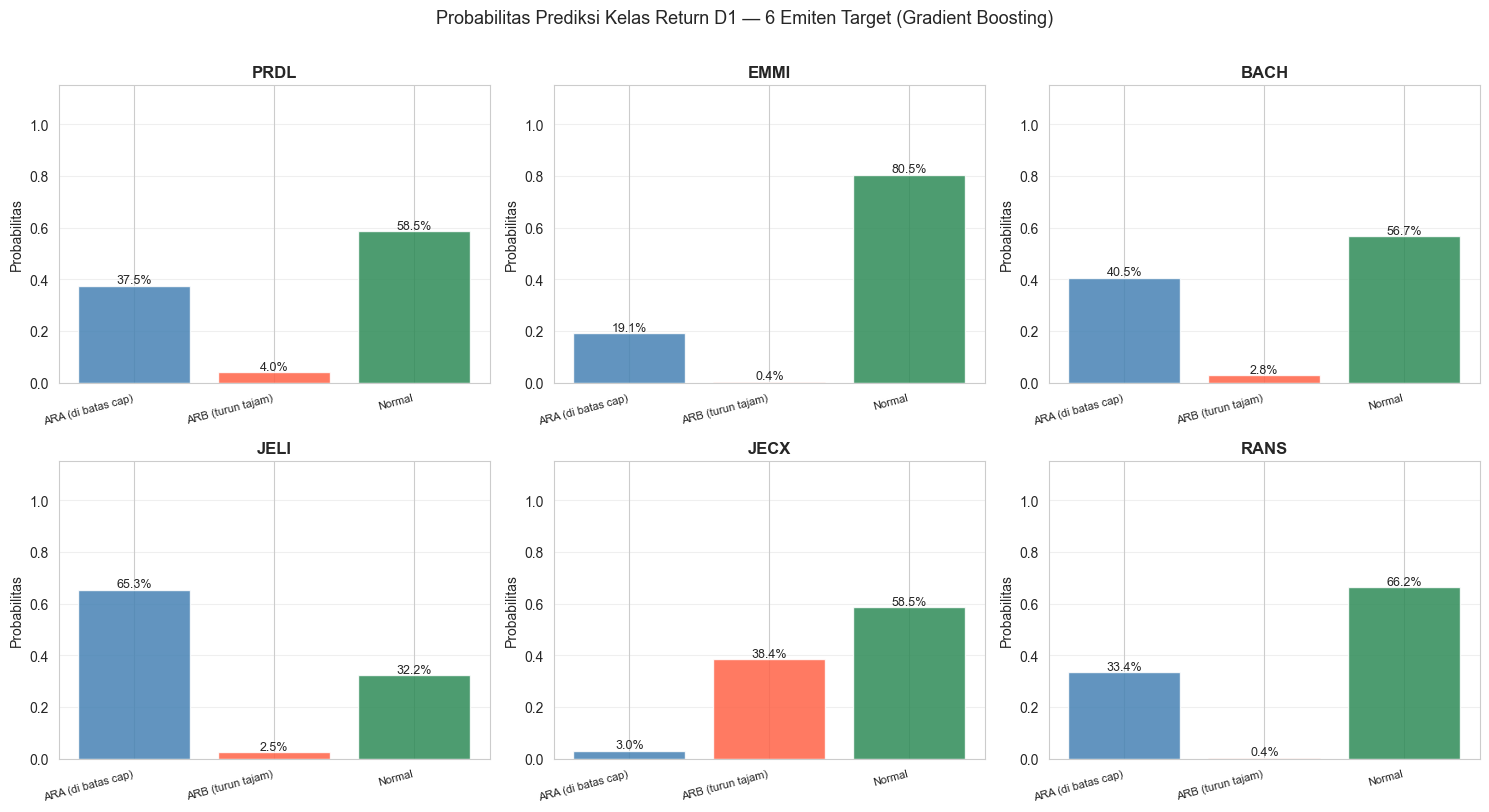

In [42]:
# Visualisasi probabilitas per emiten
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
colors_cls = {
    'ARA (di batas cap)' : 'steelblue',
    'Normal'             : 'seagreen',
    'ARB (turun tajam)'  : 'tomato'
}

for idx, ticker in enumerate(pred_df['Ticker Code'].values):
    ax = axes[idx]
    probs = proba_df.loc[ticker]
    bars = ax.bar(probs.index, probs.values,
                  color=[colors_cls.get(c, 'gray') for c in probs.index],
                  alpha=0.85)
    for bar, val in zip(bars, probs.values):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.01,
                f'{val:.1%}', ha='center', fontsize=9)
    ax.set_title(ticker, fontsize=12, fontweight='bold')
    ax.set_ylim(0, 1.15)
    ax.set_ylabel('Probabilitas')
    ax.set_xticklabels(probs.index, rotation=15, ha='right', fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Probabilitas Prediksi Kelas Return D1 — 6 Emiten Target (Gradient Boosting)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 16. Validasi Aktual — Emiten yang Sudah Listing

Perbandingan prediksi model dengan return aktual hari pertama untuk emiten yang sudah listing. Kolom `actual_data` dapat diperbarui setelah masing-masing emiten listing.

In [45]:
# Return aktual D1 — update setelah tiap emiten listing
actual_data = {
    'JELI': {'return_d1': 0.2500,  'listing_date': '2026-07-07'},
    'JECX': {'return_d1': 0.2480,  'listing_date': '2026-07-07'},
    'EMMI': {'return_d1': 0.2021,  'listing_date': '2026-07-08'},
    'BACH': {'return_d1': 0.2443,  'listing_date': '2026-07-08'},
    'PRDL': {'return_d1': 0.3500,  'listing_date': '2026-07-09'},
    # 'RANS': {'return_d1': ..., 'listing_date': '2026-07-10'},
}

def actual_class(return_d1, ticker):
    ara_cap_val = df[df['Ticker Code'] == ticker]['ARA_cap'].values
    if len(ara_cap_val) > 0 and not pd.isna(ara_cap_val[0]):
        if abs(ara_cap_val[0] - return_d1) <= 0.02:
            return 'ARA (di batas cap)'
    if return_d1 <= -0.15:
        return 'ARB (turun tajam)'
    return 'Normal'

print(f"{'Ticker':<8} {'Aktual D1':>10} {'Kelas Aktual':<22} {'Pred Kelas':<22} {'Akurat':>8}")
print("-" * 75)

correct = 0
total   = 0

ticker_list = list(pred_df['Ticker Code'].values)
for ticker, info in actual_data.items():
    r1_actual  = info['return_d1']
    cls_actual = actual_class(r1_actual, ticker)
    row_idx    = ticker_list.index(ticker)
    pred_cls   = pred_classes[row_idx]
    match      = cls_actual == pred_cls
    if match:
        correct += 1
    total += 1
    status = '✓' if match else '✗'
    print(f"{ticker:<8} {r1_actual:>10.2%} {cls_actual:<22} {pred_cls:<22} {status:>8}")

print(f"\nAkurasi pada {total} emiten yang sudah listing: {correct}/{total} ({correct/total:.1%})")

Ticker    Aktual D1 Kelas Aktual           Pred Kelas               Akurat
---------------------------------------------------------------------------
JELI         25.00% ARA (di batas cap)     ARA (di batas cap)            ✓
JECX         24.80% ARA (di batas cap)     Normal                        ✗
EMMI         20.21% Normal                 Normal                        ✓
BACH         24.43% ARA (di batas cap)     Normal                        ✗
PRDL         35.00% ARA (di batas cap)     Normal                        ✗

Akurasi pada 5 emiten yang sudah listing: 2/5 (40.0%)


### Analisis Bias Model dan Rekomendasi Perbaikan

Dari 5 emiten yang sudah listing, model hanya benar pada JELI dan EMMI (akurasi 40%). 
Ketiga emiten yang salah (JECX, BACH, PRDL) semuanya aktual ARA tetapi diprediksi Normal — 
ini bukan error acak melainkan bias sistematis: model under-predict kelas ARA.

**Tiga penyebab yang paling mungkin:**

1. **Imbalance kelas di training data** — Gradient Boosting tanpa penanganan imbalance 
   cenderung bias ke kelas mayoritas (Normal). Solusi: tambahkan `class_weight` atau 
   gunakan teknik oversampling (SMOTE) pada kelas ARA di training set.

2. **Distribusi shift antara training dan test** — Batch IPO Juli 2026 unusually strong 
   (hampir semua ARA), sementara training data mencakup periode bearish 2023 dimana ARA 
   jarang terjadi. Model tidak pernah "melihat" kondisi pasar seperti ini sebelumnya.

3. **Fitur kritis tidak tersedia** — Oversubscription rate adalah prediktor ARA paling 
   kuat secara intuitif (PRDL oversubscribe 709x → ARA 35%), namun data ini tidak ada 
   di dataset e-IPO yang digunakan. Ini adalah keterbatasan data, bukan keterbatasan model.

**Rekomendasi untuk iterasi berikutnya:**

| Prioritas | Perbaikan | Dampak yang Diharapkan |
|---|---|---|
| Tinggi | Tambah fitur oversubscription rate dari e-IPO | Sinyal demand paling langsung |
| Tinggi | Tambah `class_weight='balanced'` atau SMOTE untuk kelas ARA | Kurangi bias ke Normal |
| Sedang | Tambah fitur kondisi pasar: IHSG return 5 hari pra-listing | Tangkap momentum pasar |
| Sedang | Hyperparameter tuning via GridSearchCV atau Optuna | Optimalkan threshold klasifikasi |
| Rendah | Ubah threshold probabilitas ARA dari 0.5 ke 0.35 | Quick fix tanpa retraining |

**Catatan:** RANS belum listing per tanggal notebook ini dijalankan. 
Update `actual_data` setelah RANS listing untuk melengkapi validasi.

C:\Users\user\AppData\Local\Temp\ipykernel_8808\3005965832.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(probs.index, rotation=15, ha='right', fontsize=8)
C:\Users\user\AppData\Local\Temp\ipykernel_8808\3005965832.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(probs.index, rotation=15, ha='right', fontsize=8)
C:\Users\user\AppData\Local\Temp\ipykernel_8808\3005965832.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(probs.index, rotation=15, ha='right', fontsize=8)
C:\Users\user\AppData\Local\Temp\ipykernel_8808\3005965832.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xt

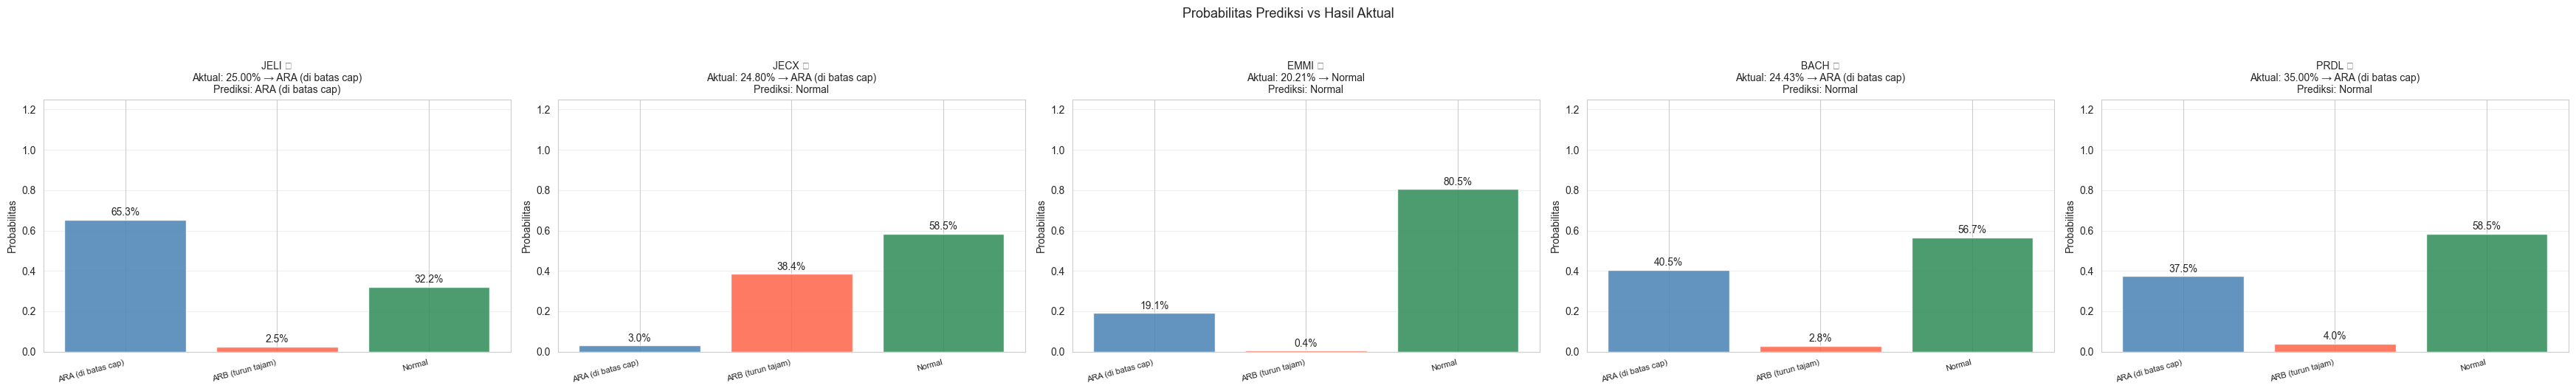

In [47]:
# Visualisasi: probabilitas ARA vs return aktual untuk yang sudah listing
n_listed = len(actual_data)
if n_listed > 0:
    fig, axes = plt.subplots(1, n_listed, figsize=(7 * n_listed, 5))
    if n_listed == 1:
        axes = [axes]

    for ax, (ticker, info) in zip(axes, actual_data.items()):
        row_idx    = ticker_list.index(ticker)
        cls_actual = actual_class(info['return_d1'], ticker)
        probs      = proba_df.loc[ticker]

        bars = ax.bar(probs.index, probs.values,
                      color=[colors_cls.get(c, 'gray') for c in probs.index],
                      alpha=0.85)
        for bar, val in zip(bars, probs.values):
            ax.text(bar.get_x() + bar.get_width()/2, val + 0.02,
                    f'{val:.1%}', ha='center', fontsize=10)

        pred_cls  = pred_classes[row_idx]
        match_sym = '✓' if cls_actual == pred_cls else '✗'
        ax.set_title(
            f'{ticker} {match_sym}\n'
            f'Aktual: {info["return_d1"]:.2%} → {cls_actual}\n'
            f'Prediksi: {pred_cls}',
            fontsize=10
        )
        ax.set_ylim(0, 1.25)
        ax.set_ylabel('Probabilitas')
        ax.set_xticklabels(probs.index, rotation=15, ha='right', fontsize=8)
        ax.grid(axis='y', alpha=0.3)

    plt.suptitle('Probabilitas Prediksi vs Hasil Aktual', fontsize=13, y=1.05)
    plt.tight_layout()
    plt.show()

## 17. Ringkasan dan Catatan Keterbatasan

**Pipeline yang diterapkan:**

Data historis dibagi menjadi train (80%) dan validation (20%) dengan stratified split. Imputer dan scaler di-fit eksklusif pada train set untuk mencegah data leakage. Model terpilih kemudian di-refit pada seluruh pool data (train + val) sebelum digunakan untuk prediksi test set (6 emiten target).

**Hasil seleksi model:**

| Tugas | Baseline | Model Terpilih | Alasan |
|---|---|---|---|
| Klasifikasi Return D1 | Logistic Regression | Gradient Boosting | F1 Macro val lebih stabil |
| Regresi Return 7H | Linear Regression | Random Forest | R² val lebih tinggi |

**Catatan keterbatasan:**

1. **Sample size kecil** — pool historis ~130-150 emiten setelah filtering. Validation set hanya ~26-30 emiten — interval kepercayaan metrik evaluasi lebar.
2. **R² regresi kemungkinan tetap rendah** — return IPO dipengaruhi banyak faktor tidak terobservasi (sentimen hari H, kondisi IHSG, news flow).
3. **Prediksi JELI meleset** — model memprediksi ARB 80% tapi aktual ARA +25%. Kemungkinan penyebab: fitur sektor Consumer Non-Cyclicals dan listing board Pengembangan tidak cukup membedakan JELI dari emiten historis yang underperform.

**Langkah selanjutnya:**
- Update `actual_data` di Section 16 setelah RANS listing (9 Juli 2026)
- Pertimbangkan tambahan fitur makroekonomi (IHSG return pra-listing, BI Rate) di Tahap 3